## Examen Restaurantes

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Ingeniería de Datos

In [28]:
users = pd.read_csv('datos/users.csv')
usercuisine = pd.read_csv('datos/usercuisine.csv')
ratings = pd.read_csv('datos/ratings.csv')
restaurants = pd.read_csv('datos/restaurants.csv')
hours = pd.read_csv('datos/hours.csv')
cuisines = pd.read_csv('datos/cuisine.csv')
users.head()

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53
4,U1005,22.183477,-100.959891,false,abstemious,no preference,family,public,single,independent,1992,none,thrifty-protector,Catholic,student,black,65,medium,1.69


In [3]:
#users.budget = users.budget.map({'low': 1, 'medium': 2, 'high': 3, '?': 0})
users['age'] = 2025 - users['birth_year']

In [4]:
users_cuisine = users.join(usercuisine.set_index('userID'), on='userID')
users_cuisine[:10]

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,interest,personality,religion,activity,color,weight,budget,height,age,Rcuisine
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,variety,thrifty-protector,none,student,black,69,medium,1.77,36,American
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,...,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87,35,Mexican
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,...,none,hard-worker,Catholic,student,blue,60,low,1.69,36,Mexican
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Bakery
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Breakfast-Brunch
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Japanese
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Contemporary
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Mexican
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Bagels
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Cafe-Coffee_Shop


In [5]:
users_ratings = users.join(ratings.set_index('userID'), on='userID')
users_ratings[:5]

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,activity,color,weight,budget,height,age,placeID,rating,food_rating,service_rating
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,132830,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,132825,2,2,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,135085,0,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,135040,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,135039,1,1,1


In [6]:
users_ratings['frequency'] =users_ratings.groupby(['userID','placeID'])['rating'].transform('count')
users_ratings = users_ratings.rename(columns={'longitude':'longitude_user','latitude':'latitude_user'})
    
users_ratings.head()

,userID,latitude_user,longitude_user,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,color,weight,budget,height,age,placeID,rating,food_rating,service_rating,frequency
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,132830,1,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,132825,2,2,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,135085,0,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,135040,1,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,135039,1,1,1,1


In [7]:
df = users_ratings.join(restaurants.set_index('placeID'), on='placeID').head()

In [8]:
from geopy.distance import geodesic

df['dist_km'] = df.apply(lambda row: geodesic((row.latitude_user, row.longitude_user), 
                                              (row.latitude, row.longitude)).kilometers, axis=1)
df.head()

,userID,latitude_user,longitude_user,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services,dist_km
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,none,informal,completely,low,?,familiar,f,closed,none,4.203769
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,none,informal,completely,low,?,familiar,f,open,none,0.930770
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,not permitted,informal,no_accessibility,medium,?,familiar,f,closed,none,1.261535
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,none,informal,no_accessibility,high,?,familiar,f,closed,none,1.056110
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,section,informal,no_accessibility,low,?,familiar,f,closed,none,0.768673


In [9]:
df.dtypes

userID               object
latitude_user       float64
longitude_user      float64
smoker               object
drink_level          object
dress_preference     object
ambience             object
transport            object
marital_status       object
hijos                object
birth_year            int64
interest             object
personality          object
religion             object
activity             object
color                object
weight                int64
budget               object
height              float64
age                   int64
placeID               int64
rating                int64
food_rating           int64
service_rating        int64
frequency             int64
latitude            float64
longitude           float64
the_geom_meter       object
name                 object
address              object
city                 object
state                object
country              object
fax                  object
zip                  object
alcohol             

In [10]:
df.corr(numeric_only=True)

,latitude_user,longitude_user,birth_year,weight,height,age,placeID,rating,food_rating,service_rating,frequency,latitude,longitude,dist_km
latitude_user,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude_user,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
birth_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
placeID,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,-0.654937,-0.613446,NaN,NaN,-0.429463,-0.442655,-0.581558
rating,NaN,NaN,NaN,NaN,NaN,NaN,-0.654937,1.000000,0.790569,NaN,NaN,-0.192874,-0.008172,-0.081089
food_rating,NaN,NaN,NaN,NaN,NaN,NaN,-0.613446,0.790569,1.000000,NaN,NaN,0.114611,-0.409938,-0.276534
service_rating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


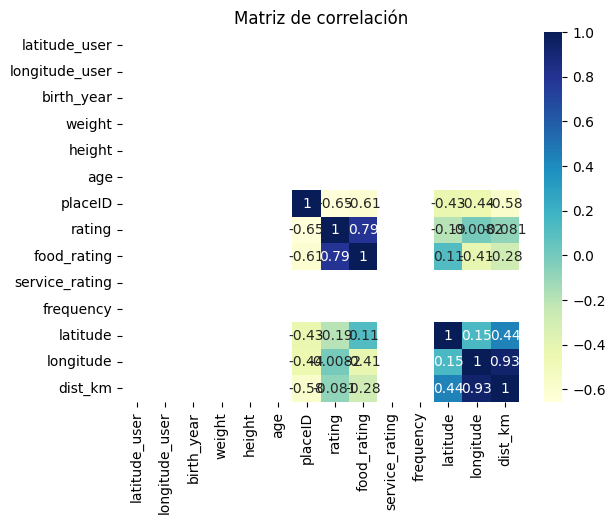

In [11]:
# Matriz de correlación
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Matriz de correlación")
plt.show()

### Análisis restaurantes

In [12]:
ratings_mean = ratings.groupby('placeID')['rating'].mean().reset_index()
ratings_mean.head()

,placeID,rating
0,132560,0.50
1,132561,0.75
2,132564,1.25
3,132572,1.00
4,132583,1.00


In [13]:
rest_rating =restaurants.join(ratings_mean.set_index('placeID'), on='placeID')
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services,rating
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,none,informal,no_accessibility,medium,kikucuernavaca.com.mx,familiar,f,closed,none,1.600000
1,132825,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,?,...,none,informal,completely,low,?,familiar,f,open,none,1.281250
2,135106,22.149709,-100.976093,0101000020957F0000649D6F21634858C119AE9BF528A3...,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,?,...,only at bar,informal,partially,medium,?,familiar,f,open,none,1.200000
3,132667,23.752697,-99.163359,0101000020957F00005D67BCDDED8157C1222A2DC8D84D...,little pizza Emilio Portes Gil,calle emilio portes gil,victoria,tamaulipas,?,?,...,none,informal,completely,low,?,familiar,t,closed,none,1.250000
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,permitted,informal,completely,medium,?,familiar,t,closed,none,1.166667


In [14]:
rest_rating.price = rest_rating.price.map({'low': 1, 'medium': 2, 'high': 3})
rest_rating.franchise = rest_rating.franchise.map({'t': 0, 'f': 1})

In [18]:
rest_rating['number_of_cuisines'] = cuisines.groupby('placeID')['Rcuisine'].transform('count')
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,dress_code,accessibility,price,url,Rambience,franchise,area,other_services,rating,number_of_cuisines
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,informal,no_accessibility,2,kikucuernavaca.com.mx,familiar,1,closed,none,1.600000,1
1,132825,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,?,...,informal,completely,1,?,familiar,1,open,none,1.281250,1
2,135106,22.149709,-100.976093,0101000020957F0000649D6F21634858C119AE9BF528A3...,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,?,...,informal,partially,2,?,familiar,1,open,none,1.200000,1
3,132667,23.752697,-99.163359,0101000020957F00005D67BCDDED8157C1222A2DC8D84D...,little pizza Emilio Portes Gil,calle emilio portes gil,victoria,tamaulipas,?,?,...,informal,completely,1,?,familiar,0,closed,none,1.250000,1
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,informal,completely,2,?,familiar,0,closed,none,1.166667,1


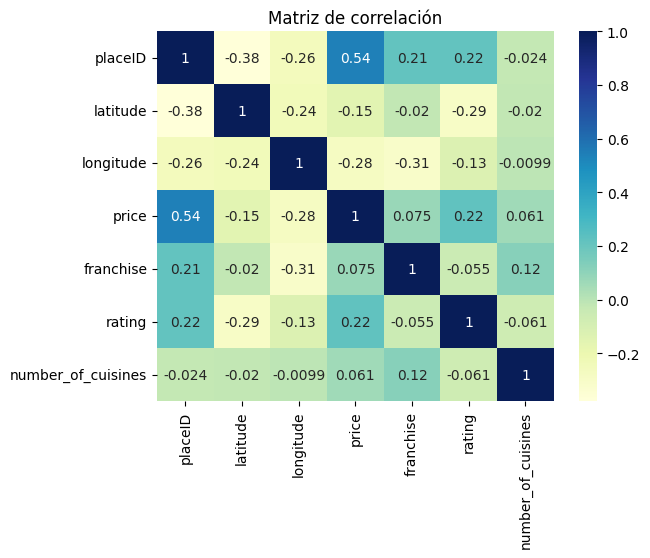

In [19]:
# Matriz de correlación
corr = rest_rating.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Matriz de correlación")
plt.show()

In [32]:
hours.head()

,placeID,hours,days
0,135111,00:00-23:30;,Mon;Tue;Wed;Thu;Fri;
1,135111,00:00-23:30;,Sat;
2,135111,00:00-23:30;,Sun;
3,135110,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;
4,135110,00:00-00:00;,Sat;


In [37]:
hours.pivot(index='placeID', columns='days', values='hours').head()

ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
hours['opening_time'] = hours['hours'].str.split('-').str[0].astype(str)
hours['closing_time'] = hours['hours'].str.split('-').str[1].astype(str)